<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Trabalho---PROCSIN/blob/main/Gr%C3%A1ficos_PROCSIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 29.0 MB/s eta 0:00:00


In [ ]:
import fitz

pdf_path = '/content/Trabalho___2026_1.pdf'
doc = fitz.open(pdf_path)
text = ""
for page in doc:
    text += page.get_text()

print("Conteúdo do PDF extraído com sucesso. Analisando requisitos...")
print(text[:2000]) # Exibindo o início para contexto

Conteúdo do PDF extraído com sucesso. Analisando requisitos...
Prof. Rafael S. Chaves
Processamento de Sinais I
Modelagem e An´alise de Arranjos de Sensores
1
Objetivos
Este trabalho tem como objetivo introduzir conceitos
fundamentais de processamento espacial de sinais por
meio da modelagem e an´alise de arranjos de sensores.
Ao final da atividade, o aluno dever´a ser capaz de:
• Modelar
diferentes
geometrias
de
arranjos
de
sensores;
• Implementar fun¸c˜oes para gera¸c˜ao de canais de pro-
paga¸c˜ao;
• Compreender o conceito de vetor diretor (steering
vector);
• Implementar t´ecnicas b´asicas de beamforming;
• Calcular e interpretar diagramas de radia¸c˜ao (beam-
patterns);
• Avaliar a influˆencia da geometria do arranjo na re-
cep¸c˜ao de sinais;
• Relacionar ganho espacial, diretividade e potˆencia
recebida.
2
Fundamenta¸c˜ao Te´orica
Pesquise e apresente uma breve revis˜ao sobre:
1. Arranjos de sensores;
2. Processamento espacial de sinais;
3. Vetor diretor (steering vector);
4. Be


--- DESTAQUE ---
NOME: Diagrama de Radiação - ULA (Uniform Linear Array)
TIPO: Resposta Angular (Magnitude em dB)
MODELO: M=10 sensores, espaçamento λ/2


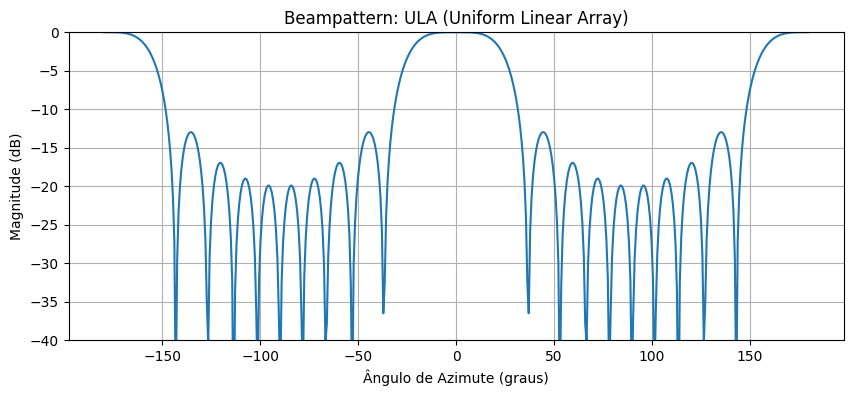


--- DESTAQUE ---
NOME: Diagrama de Radiação - UPA (Uniform Planar Array)
TIPO: Resposta Angular (Magnitude em dB)
MODELO: 5x5 sensores, plano XY


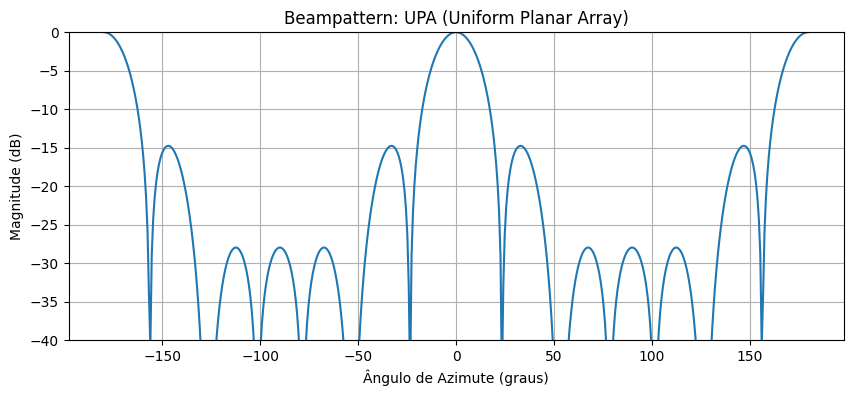


--- DESTAQUE ---
NOME: Diagrama de Radiação - UCA (Uniform Circular Array)
TIPO: Resposta Angular (Magnitude em dB)
MODELO: M=12 sensores, Raio=λ


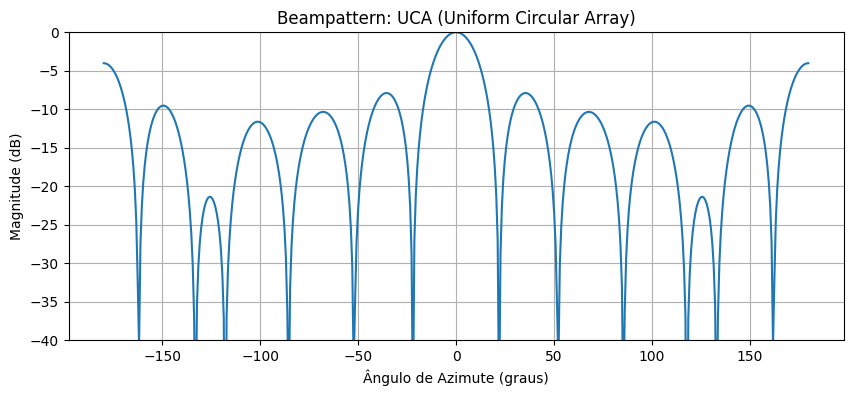

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_steering_vector(coords, theta, phi, lam):
    """Calcula o vetor diretor para coordenadas (M, 3)."""
    k = 2 * np.pi / lam
    # Vetor unitário de propagação (u)
    u = np.array([
        np.cos(theta) * np.cos(phi),
        np.cos(theta) * np.sin(phi),
        np.sin(theta)
    ])
    # a = exp(-j * k * r.u)
    return np.exp(-1j * k * (coords @ u))

def plot_beampattern_2d(coords, w, lam, title, array_name):
    """Gera o gráfico do fator de arranjo normalizado."""
    phi_range = np.linspace(-np.pi, np.pi, 500)
    theta_fixed = 0
    af_vals = []

    for p in phi_range:
        a = get_steering_vector(coords, theta_fixed, p, lam)
        af = np.abs(np.vdot(w, a))
        af_vals.append(af)

    af_vals = np.array(af_vals)
    af_vals /= np.max(af_vals)

    print(f"\n--- DESTAQUE ---")
    print(f"NOME: Diagrama de Radiação - {array_name}")
    print(f"TIPO: Resposta Angular (Magnitude em dB)")
    print(f"MODELO: {title}")

    plt.figure(figsize=(10, 4))
    plt.plot(np.degrees(phi_range), 20 * np.log10(af_vals + 1e-10))
    plt.title(f"Beampattern: {array_name}")
    plt.xlabel("Ângulo de Azimute (graus)")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)
    plt.ylim([-40, 0])
    plt.show()

# Parâmetros gerais
lam = 1.0
d = lam / 2

# 1. ARRANJO LINEAR UNIFORME (ULA)
M_ula = 10
ula_coords = np.zeros((M_ula, 3))
ula_coords[:, 0] = np.arange(M_ula) * d
w_ula = get_steering_vector(ula_coords, 0, 0, lam) # Beam para 0°
plot_beampattern_2d(ula_coords, w_ula, lam, "M=10 sensores, espaçamento λ/2", "ULA (Uniform Linear Array)")

# 2. ARRANJO PLANAR UNIFORME (UPA)
M_x, M_y = 5, 5
upa_coords = []
for i in range(M_x):
    for j in range(M_y):
        upa_coords.append([i * d, j * d, 0])
upa_coords = np.array(upa_coords)
w_upa = get_steering_vector(upa_coords, 0, 0, lam)
plot_beampattern_2d(upa_coords, w_upa, lam, f"{M_x}x{M_y} sensores, plano XY", "UPA (Uniform Planar Array)")

# 3. ARRANJO CIRCULAR UNIFORME (UCA)
M_uca = 12
radius = lam
angles = np.linspace(0, 2*np.pi, M_uca, endpoint=False)
uca_coords = np.zeros((M_uca, 3))
uca_coords[:, 0] = radius * np.cos(angles)
uca_coords[:, 1] = radius * np.sin(angles)
w_uca = get_steering_vector(uca_coords, 0, 0, lam)
plot_beampattern_2d(uca_coords, w_uca, lam, f"M={M_uca} sensores, Raio=λ", "UCA (Uniform Circular Array)")

### Implementação de todos os cenários solicitados no PDF

Nesta seção, realizamos os experimentos detalhados no roteiro, incluindo variações de número de elementos ($M$), distância entre elementos ($d$) e ângulos de apontamento.


--- DESTAQUE ---
NOME: ULA M=4
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, d=0.5λ, aponta 0°


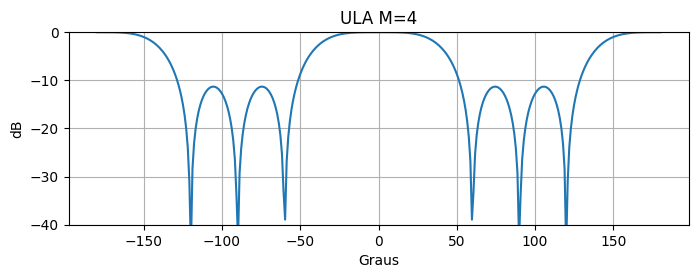


--- DESTAQUE ---
NOME: ULA M=8
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, d=0.5λ, aponta 0°


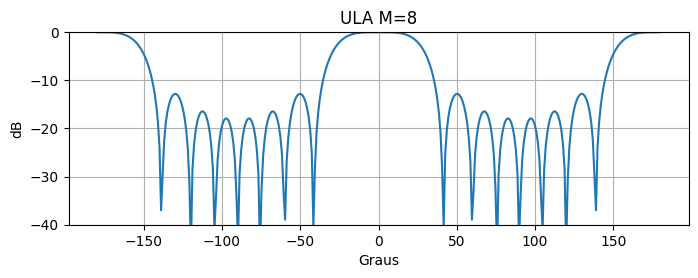


--- DESTAQUE ---
NOME: ULA M=16
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, d=0.5λ, aponta 0°


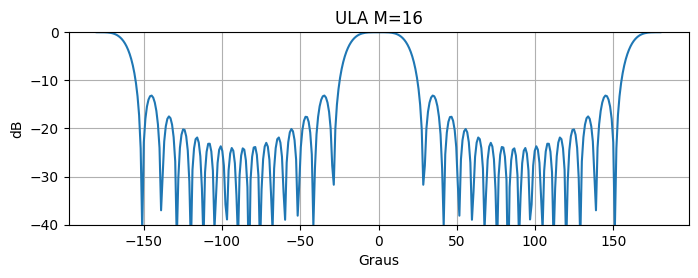


--- DESTAQUE ---
NOME: ULA d=0.1λ
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, aponta 0°


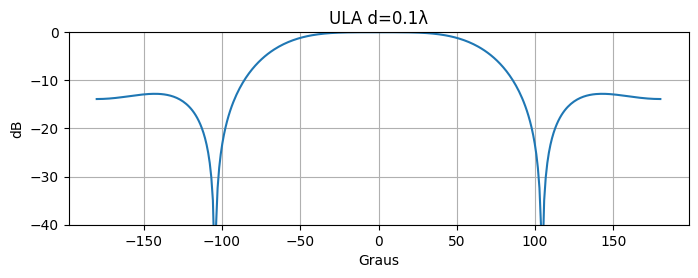


--- DESTAQUE ---
NOME: ULA d=0.5λ
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, aponta 0°


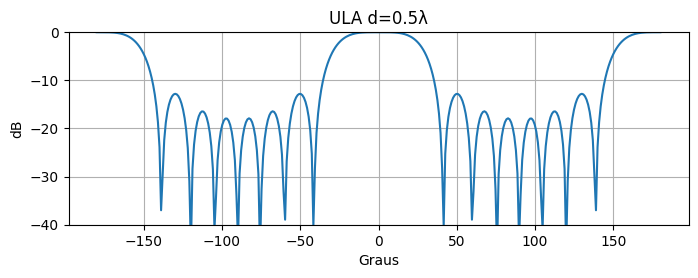


--- DESTAQUE ---
NOME: ULA d=1.2λ
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, aponta 0°


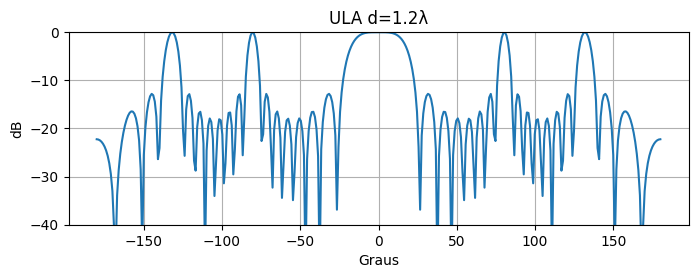


--- DESTAQUE ---
NOME: ULA Beam 30°
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, d=0.5λ


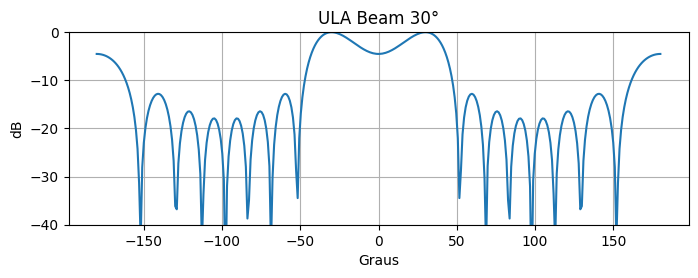


--- DESTAQUE ---
NOME: ULA Beam 60°
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, d=0.5λ


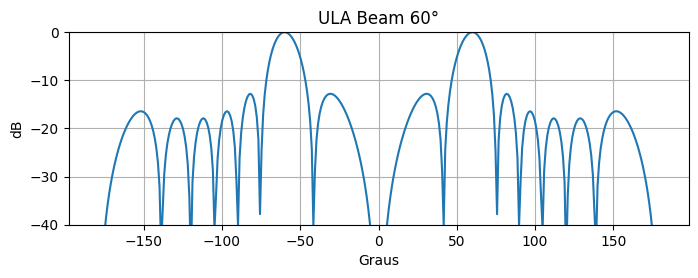


--- DESTAQUE ---
NOME: UPA 4x4
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Planar, d=0.5λ, aponta 0°


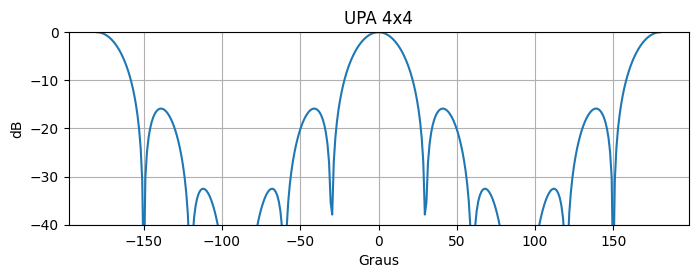


--- DESTAQUE ---
NOME: UCA M=8
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Circular, Raio=λ, aponta 0°


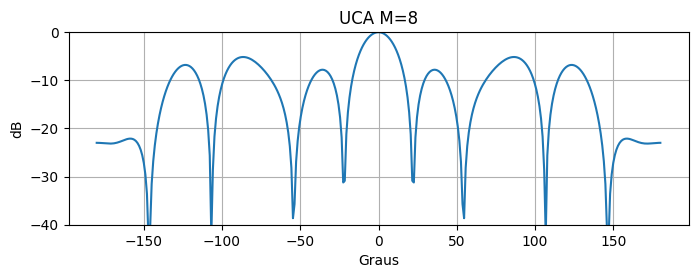

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_steering_vector(coords, theta, phi, lam=1.0):
    k = 2 * np.pi / lam
    u = np.array([np.cos(theta) * np.cos(phi), np.cos(theta) * np.sin(phi), np.sin(theta)])
    return np.exp(-1j * k * (coords @ u))

def plot_scenario(coords, w, name, model_desc, lam=1.0):
    phi_range = np.linspace(-np.pi, np.pi, 360)
    af_vals = [np.abs(np.vdot(w, get_steering_vector(coords, 0, p, lam))) for p in phi_range]
    af_vals = np.array(af_vals) / np.max(af_vals)

    print(f"\n--- DESTAQUE ---\nNOME: {name}\nTIPO: Diagrama de Radiação (dB)\nMODELO: {model_desc}")
    plt.figure(figsize=(8, 2.5))
    plt.plot(np.degrees(phi_range), 20 * np.log10(af_vals + 1e-10))
    plt.title(name); plt.xlabel("Graus"); plt.ylabel("dB"); plt.grid(True); plt.ylim([-40, 0])
    plt.show()

lam = 1.0
# 1. Variação de M (ULA, d=0.5)
for M in [4, 8, 16]:
    c = np.column_stack((np.arange(M)*0.5*lam, np.zeros((M, 2))))
    plot_scenario(c, get_steering_vector(c, 0, 0), f"ULA M={M}", f"Arranjo Linear, d=0.5λ, aponta 0°")

# 2. Variação de d (ULA, M=8)
for d_f in [0.1, 0.5, 1.2]:
    c = np.column_stack((np.arange(8)*d_f*lam, np.zeros((8, 2))))
    plot_scenario(c, get_steering_vector(c, 0, 0), f"ULA d={d_f}λ", f"Arranjo Linear, M=8, aponta 0°")

# 3. Variação de Ângulo (ULA, M=8, d=0.5)
c_ula = np.column_stack((np.arange(8)*0.5*lam, np.zeros((8, 2))))
for ang in [30, 60]:
    plot_scenario(c_ula, get_steering_vector(c_ula, 0, np.radians(ang)), f"ULA Beam {ang}°", f"Arranjo Linear, M=8, d=0.5λ")

# 4. Geometrias Especiais
upa = np.array([[i*0.5, j*0.5, 0] for i in range(4) for j in range(4)])
plot_scenario(upa, get_steering_vector(upa, 0, 0), "UPA 4x4", "Arranjo Planar, d=0.5λ, aponta 0°")

uca_ang = np.linspace(0, 2*np.pi, 8, endpoint=False)
uca = np.column_stack((np.cos(uca_ang), np.sin(uca_ang), np.zeros(8)))
plot_scenario(uca, get_steering_vector(uca, 0, 0), "UCA M=8", "Arranjo Circular, Raio=λ, aponta 0°")


--- DESTAQUE ---
NOME: ULA d=0.1λ
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, aponta 0°


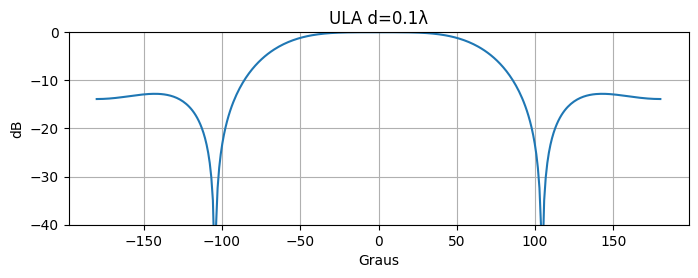


--- DESTAQUE ---
NOME: ULA d=0.5λ
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, aponta 0°


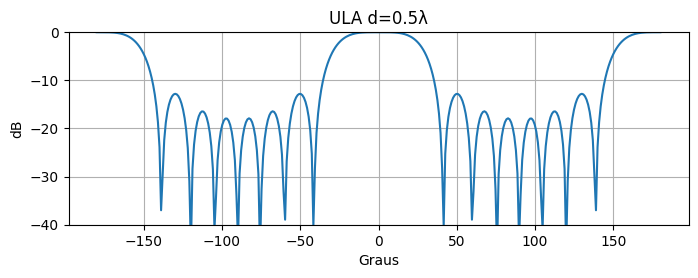


--- DESTAQUE ---
NOME: ULA d=1.2λ
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, aponta 0°


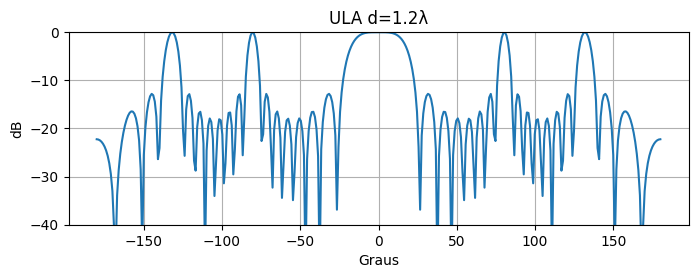

In [ ]:
# 2. Variação de espaçamento (d) para ULA M=8
for d_f in [0.1, 0.5, 1.2]:
    c = np.column_stack((np.arange(8)*d_f*lam, np.zeros((8, 2))))
    plot_scenario(c, get_steering_vector(c, 0, 0), f"ULA d={d_f}λ", f"Arranjo Linear, M=8, aponta 0°")


--- DESTAQUE ---
NOME: ULA Beam 30°
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, d=0.5λ


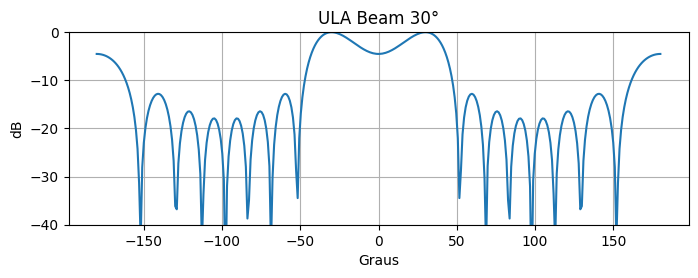


--- DESTAQUE ---
NOME: ULA Beam 60°
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Linear, M=8, d=0.5λ


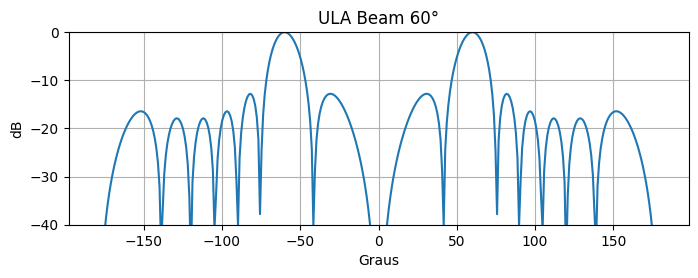

In [ ]:
# 3. Variação de Ângulo de Apontamento para ULA M=8, d=0.5λ
c_ula_fixed = np.column_stack((np.arange(8)*0.5*lam, np.zeros((8, 2))))
for ang in [30, 60]:
    plot_scenario(c_ula_fixed, get_steering_vector(c_ula_fixed, 0, np.radians(ang)), f"ULA Beam {ang}°", f"Arranjo Linear, M=8, d=0.5λ")


--- DESTAQUE ---
NOME: UPA 4x4
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Planar, d=0.5λ, aponta 0°


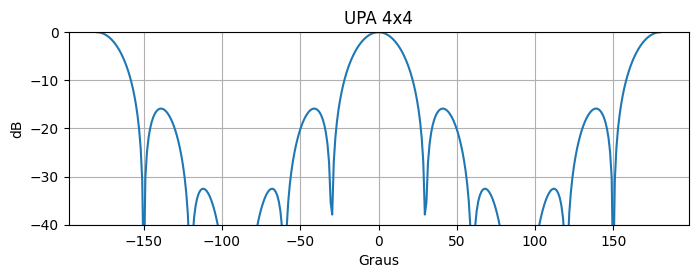


--- DESTAQUE ---
NOME: UCA M=8
TIPO: Diagrama de Radiação (dB)
MODELO: Arranjo Circular, Raio=λ, aponta 0°


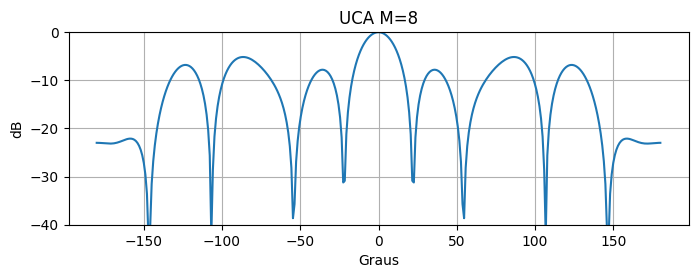

In [ ]:
# 4. Geometrias Especiais: UPA (Planar) e UCA (Circular)
# UPA 4x4
upa_coords = np.array([[i*0.5, j*0.5, 0] for i in range(4) for j in range(4)])
plot_scenario(upa_coords, get_steering_vector(upa_coords, 0, 0), "UPA 4x4", "Arranjo Planar, d=0.5λ, aponta 0°")

# UCA M=8
uca_ang_pts = np.linspace(0, 2*np.pi, 8, endpoint=False)
uca_coords_pts = np.column_stack((np.cos(uca_ang_pts), np.sin(uca_ang_pts), np.zeros(8)))
plot_scenario(uca_coords_pts, get_steering_vector(uca_coords_pts, 0, 0), "UCA M=8", "Arranjo Circular, Raio=λ, aponta 0°")

### Geração de Heatmaps de Radiação (Azimute vs. Elevação)

Nesta seção, expandimos a análise para o espaço 2D, gerando mapas de calor que mostram a intensidade do feixe em função de diferentes ângulos de Azimute e Elevação.


--- DESTAQUE ---
NOME: Heatmap de Radiação - ULA M=8
TIPO: Mapa de Calor (Azimute vs Elevação)
MODELO: Arranjo Linear Uniforme, d=0.5λ, aponta (0,0)


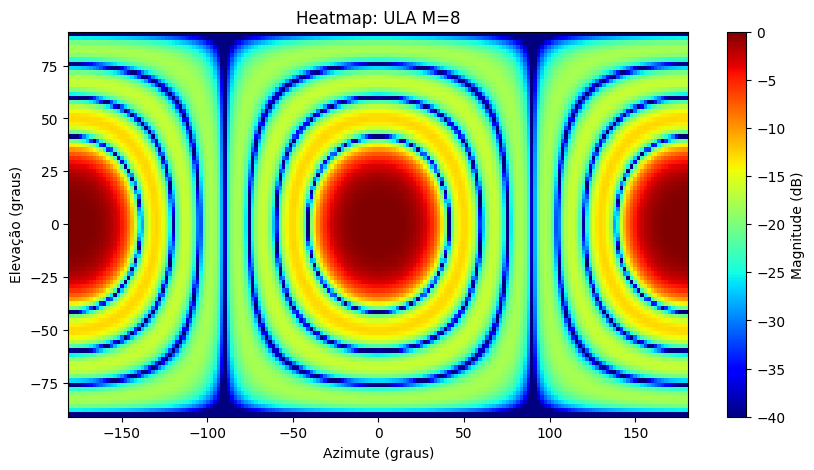


--- DESTAQUE ---
NOME: Heatmap de Radiação - UPA 4x4
TIPO: Mapa de Calor (Azimute vs Elevação)
MODELO: Arranjo Planar Uniforme, d=0.5λ, aponta (0,0)


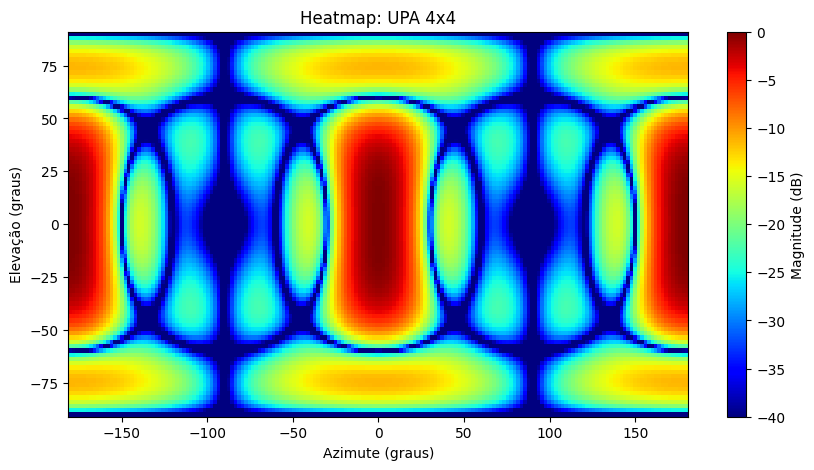

In [ ]:
def plot_beampattern_heatmap(coords, w, name, model_desc, lam=1.0):
    # Definição da malha angular
    azimuths = np.linspace(-np.pi, np.pi, 180)
    elevations = np.linspace(-np.pi/2, np.pi/2, 90)
    AZ, EL = np.meshgrid(azimuths, elevations)

    # Cálculo da resposta para cada par (theta, phi)
    responses = np.zeros(AZ.shape)

    for i in range(len(elevations)):
        for j in range(len(azimuths)):
            a = get_steering_vector(coords, EL[i,j], AZ[i,j], lam)
            responses[i,j] = np.abs(np.vdot(w, a))

    responses /= np.max(responses)
    responses_db = 20 * np.log10(responses + 1e-10)

    print(f"\n--- DESTAQUE ---\nNOME: Heatmap de Radiação - {name}\nTIPO: Mapa de Calor (Azimute vs Elevação)\nMODELO: {model_desc}")

    plt.figure(figsize=(10, 5))
    plt.pcolormesh(np.degrees(azimuths), np.degrees(elevations), responses_db, shading='auto', cmap='jet', vmin=-40, vmax=0)
    plt.colorbar(label='Magnitude (dB)')
    plt.title(f'Heatmap: {name}')
    plt.xlabel('Azimute (graus)')
    plt.ylabel('Elevação (graus)')
    plt.show()

# Gerando Heatmap para ULA (M=8, d=0.5λ)
ula_8 = np.column_stack((np.arange(8)*0.5, np.zeros((8, 2))))
w_ula_8 = get_steering_vector(ula_8, 0, 0)
plot_beampattern_heatmap(ula_8, w_ula_8, "ULA M=8", "Arranjo Linear Uniforme, d=0.5λ, aponta (0,0)")

# Gerando Heatmap para UPA (4x4, d=0.5λ)
upa_4x4 = np.array([[i*0.5, j*0.5, 0] for i in range(4) for j in range(4)])
w_upa_4x4 = get_steering_vector(upa_4x4, 0, 0)
plot_beampattern_heatmap(upa_4x4, w_upa_4x4, "UPA 4x4", "Arranjo Planar Uniforme, d=0.5λ, aponta (0,0)")


--- DESTAQUE ---
NOME: Heatmap de Radiação - UCA M=12
TIPO: Mapa de Calor (Azimute vs Elevação)
MODELO: Arranjo Circular Uniforme, Raio=λ, aponta (0,0)


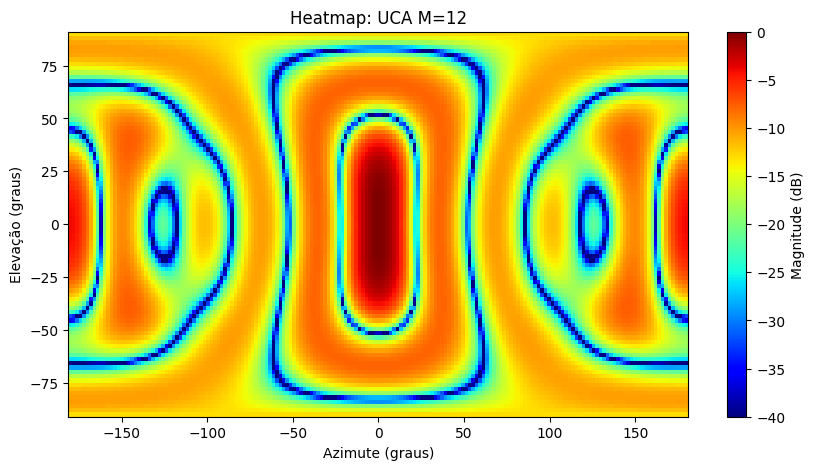

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def get_steering_vector(coords, theta, phi, lam):
    """Calcula o vetor diretor para coordenadas (M, 3)."""
    k = 2 * np.pi / lam
    # Vetor unitário de propagação (u)
    u = np.array([
        np.cos(theta) * np.cos(phi),
        np.cos(theta) * np.sin(phi),
        np.sin(theta)
    ])
    # a = exp(-j * k * r.u)
    return np.exp(-1j * k * (coords @ u))

def plot_beampattern_heatmap(coords, w, name, model_desc, lam=1.0):
    # Definição da malha angular
    azimuths = np.linspace(-np.pi, np.pi, 180)
    elevations = np.linspace(-np.pi/2, np.pi/2, 90)
    AZ, EL = np.meshgrid(azimuths, elevations)

    # Cálculo da resposta para cada par (theta, phi)
    responses = np.zeros(AZ.shape)

    for i in range(len(elevations)):
        for j in range(len(azimuths)):
            a = get_steering_vector(coords, EL[i,j], AZ[i,j], lam)
            responses[i,j] = np.abs(np.vdot(w, a))

    responses /= np.max(responses)
    responses_db = 20 * np.log10(responses + 1e-10)

    print(f"\n--- DESTAQUE ---\nNOME: Heatmap de Radiação - {name}\nTIPO: Mapa de Calor (Azimute vs Elevação)\nMODELO: {model_desc}")

    plt.figure(figsize=(10, 5))
    plt.pcolormesh(np.degrees(azimuths), np.degrees(elevations), responses_db, shading='auto', cmap='jet', vmin=-40, vmax=0)
    plt.colorbar(label='Magnitude (dB)')
    plt.title(f'Heatmap: {name}')
    plt.xlabel('Azimute (graus)')
    plt.ylabel('Elevação (graus)')
    plt.show()

lam = 1.0 # Definindo o comprimento de onda

# Gerando Heatmap para UCA (M=12, Raio=λ)
M_uca_heatmap = 12
radius_uca_heatmap = lam
angles_uca_heatmap = np.linspace(0, 2*np.pi, M_uca_heatmap, endpoint=False)
uca_coords_heatmap = np.zeros((M_uca_heatmap, 3))
uca_coords_heatmap[:, 0] = radius_uca_heatmap * np.cos(angles_uca_heatmap)
uca_coords_heatmap[:, 1] = radius_uca_heatmap * np.sin(angles_uca_heatmap)

w_uca_heatmap = get_steering_vector(uca_coords_heatmap, 0, 0, lam)
plot_beampattern_heatmap(uca_coords_heatmap, w_uca_heatmap, "UCA M=12", "Arranjo Circular Uniforme, Raio=λ, aponta (0,0)")

### Visualização 3D e Diagramas Polares

Para uma análise completa, apresentamos o beampattern em representação tridimensional (ganho espacial) e em coordenadas polares.


--- DESTAQUE ---
NOME: Diagrama Polar - ULA M=8
TIPO: Representação Polar (dB)
MODELO: Arranjo Linear Uniforme, d=0.5λ


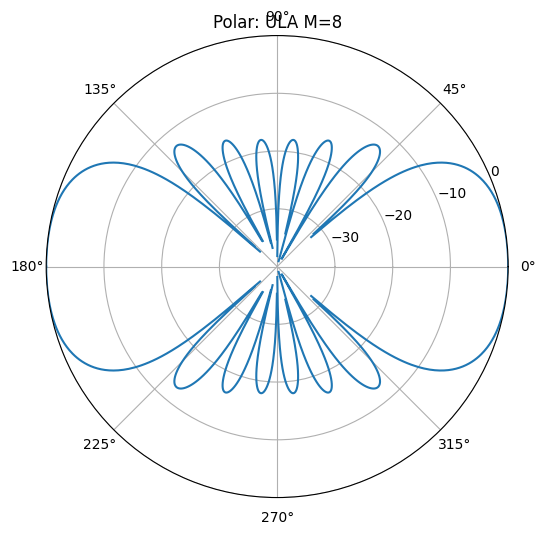


--- DESTAQUE ---
NOME: Diagrama 3D - UPA 4x4
TIPO: Ganho Espacial 3D (Linear)
MODELO: Arranjo Planar Uniforme, d=0.5λ


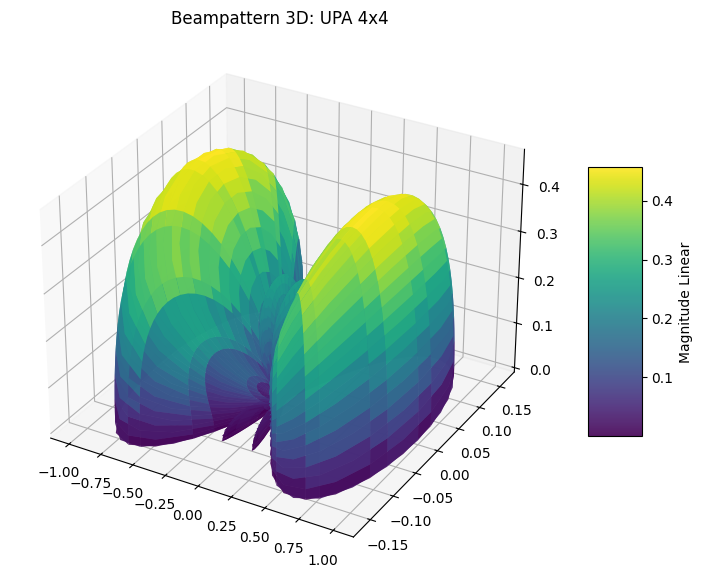

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

def plot_beampattern_3d(coords, w, name, model_desc, lam=1.0):
    # Malha angular para 3D
    phi = np.linspace(0, 2*np.pi, 100)
    theta = np.linspace(0, np.pi, 100)
    PHI, THETA = np.meshgrid(phi, theta)

    # Inicializa R
    R = np.zeros(PHI.shape)

    # Cálculo da intensidade
    for i in range(len(theta)):
        for j in range(len(phi)):
            # Nota: u usa a convenção do PDF (u_z = sin theta)
            u = np.array([
                np.cos(THETA[i,j]) * np.cos(PHI[i,j]),
                np.cos(THETA[i,j]) * np.sin(PHI[i,j]),
                np.sin(THETA[i,j])
            ])
            af = np.abs(np.vdot(w, np.exp(-1j * (2*np.pi/lam) * (coords @ u))))
            R[i,j] = af

    R /= np.max(R)

    # Conversão para coordenadas cartesianas para plotagem 3D
    X = R * np.cos(THETA) * np.cos(PHI)
    Y = R * np.cos(THETA) * np.sin(PHI)
    Z = R * np.sin(THETA)

    print(f"\n--- DESTAQUE ---\nNOME: Diagrama 3D - {name}\nTIPO: Ganho Espacial 3D (Linear)\nMODELO: {model_desc}")

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Magnitude Linear')
    ax.set_title(f'Beampattern 3D: {name}')
    plt.show()

def plot_beampattern_polar(coords, w, name, model_desc, lam=1.0):
    angles = np.linspace(-np.pi, np.pi, 1000)
    resp = [np.abs(np.vdot(w, get_steering_vector(coords, 0, a, lam))) for a in angles]
    resp = np.array(resp) / np.max(resp)

    print(f"\n--- DESTAQUE ---\nNOME: Diagrama Polar - {name}\nTIPO: Representação Polar (dB)\nMODELO: {model_desc}")

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, projection='polar')
    ax.plot(angles, 20 * np.log10(resp + 1e-10))
    ax.set_rticks([-30, -20, -10, 0])
    ax.set_rmin(-40)
    ax.set_title(f'Polar: {name}')
    plt.show()

# Exemplos de visualização para fechar o conjunto de pedidos
plot_beampattern_polar(ula_8, w_ula_8, "ULA M=8", "Arranjo Linear Uniforme, d=0.5λ")
plot_beampattern_3d(upa_4x4, w_upa_4x4, "UPA 4x4", "Arranjo Planar Uniforme, d=0.5λ")


--- DESTAQUE ---
NOME: Diagrama 3D - ULA M=8
TIPO: Ganho Espacial 3D (Linear)
MODELO: Arranjo Linear Uniforme, d=0.5λ


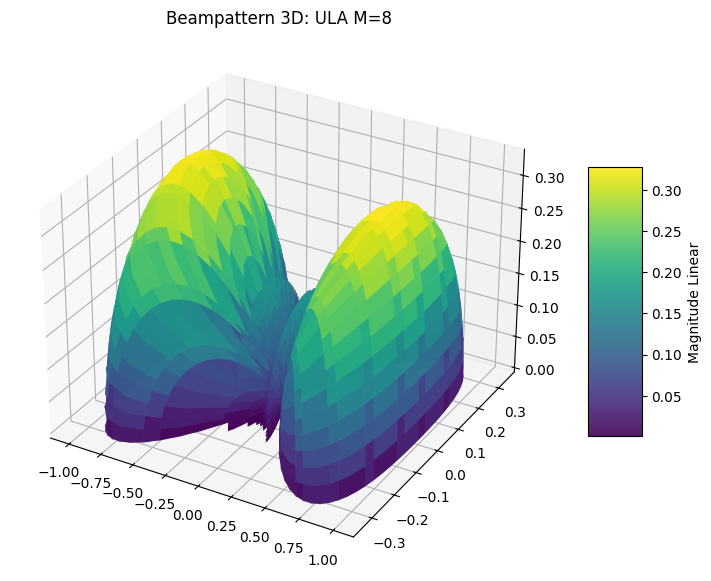

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_steering_vector(coords, theta, phi, lam):
    k = 2 * np.pi / lam
    u = np.array([
        np.cos(theta) * np.cos(phi),
        np.cos(theta) * np.sin(phi),
        np.sin(theta)
    ])
    return np.exp(-1j * k * (coords @ u))

def plot_beampattern_3d(coords, w, name, model_desc, lam=1.0):
    phi = np.linspace(0, 2*np.pi, 100)
    theta = np.linspace(0, np.pi, 100)
    PHI, THETA = np.meshgrid(phi, theta)
    R = np.zeros(PHI.shape)

    for i in range(len(theta)):
        for j in range(len(phi)):
            u = np.array([
                np.cos(THETA[i,j]) * np.cos(PHI[i,j]),
                np.cos(THETA[i,j]) * np.sin(PHI[i,j]),
                np.sin(THETA[i,j])
            ])
            af = np.abs(np.vdot(w, np.exp(-1j * (2*np.pi/lam) * (coords @ u))))
            R[i,j] = af

    R /= np.max(R)
    X = R * np.cos(THETA) * np.cos(PHI)
    Y = R * np.cos(THETA) * np.sin(PHI)
    Z = R * np.sin(THETA)

    print(f"\n--- DESTAQUE ---\nNOME: Diagrama 3D - {name}\nTIPO: Ganho Espacial 3D (Linear)\nMODELO: {model_desc}")

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Magnitude Linear')
    ax.set_title(f'Beampattern 3D: {name}')
    plt.show()

lam = 1.0
d = lam / 2
M_ula = 8
ula_coords = np.zeros((M_ula, 3))
ula_coords[:, 0] = np.arange(M_ula) * d
w_ula = get_steering_vector(ula_coords, 0, 0, lam)

plot_beampattern_3d(ula_coords, w_ula, "ULA M=8", "Arranjo Linear Uniforme, d=0.5λ")


--- DESTAQUE ---
NOME: Diagrama 3D - UCA M=8
TIPO: Ganho Espacial 3D (Linear)
MODELO: Arranjo Circular Uniforme, Raio=λ


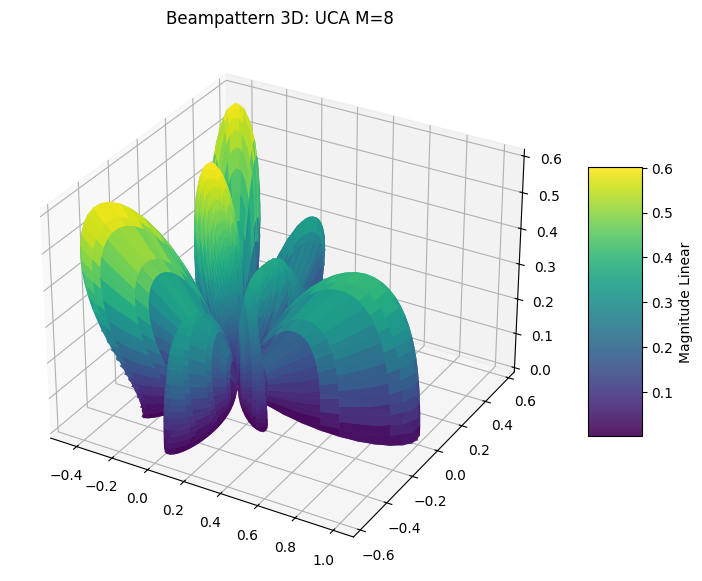

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_steering_vector(coords, theta, phi, lam):
    k = 2 * np.pi / lam
    u = np.array([
        np.cos(theta) * np.cos(phi),
        np.cos(theta) * np.sin(phi),
        np.sin(theta)
    ])
    return np.exp(-1j * k * (coords @ u))

def plot_beampattern_3d(coords, w, name, model_desc, lam=1.0):
    phi = np.linspace(0, 2*np.pi, 100)
    theta = np.linspace(0, np.pi, 100)
    PHI, THETA = np.meshgrid(phi, theta)
    R = np.zeros(PHI.shape)

    for i in range(len(theta)):
        for j in range(len(phi)):
            u = np.array([
                np.cos(THETA[i,j]) * np.cos(PHI[i,j]),
                np.cos(THETA[i,j]) * np.sin(PHI[i,j]),
                np.sin(THETA[i,j])
            ])
            af = np.abs(np.vdot(w, np.exp(-1j * (2*np.pi/lam) * (coords @ u))))
            R[i,j] = af

    R /= np.max(R)
    X = R * np.cos(THETA) * np.cos(PHI)
    Y = R * np.cos(THETA) * np.sin(PHI)
    Z = R * np.sin(THETA)

    print(f"\n--- DESTAQUE ---\nNOME: Diagrama 3D - {name}\nTIPO: Ganho Espacial 3D (Linear)\nMODELO: {model_desc}")

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Magnitude Linear')
    ax.set_title(f'Beampattern 3D: {name}')
    plt.show()

lam = 1.0
M_uca = 8
radius = lam
angles = np.linspace(0, 2*np.pi, M_uca, endpoint=False)
uca_coords = np.zeros((M_uca, 3))
uca_coords[:, 0] = radius * np.cos(angles)
uca_coords[:, 1] = radius * np.sin(angles)
w_uca = get_steering_vector(uca_coords, 0, 0, lam)

plot_beampattern_3d(uca_coords, w_uca, "UCA M=8", "Arranjo Circular Uniforme, Raio=λ")

### Visualização das Geometrias dos Arranjos em 3D

Abaixo, plotamos as posições tridimensionais dos sensores para cada tipo de arranjo solicitado, incluindo o arranjo cilíndrico (que combina um círculo com múltiplas camadas verticais).

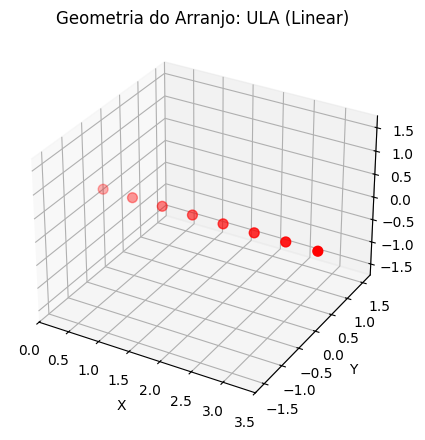

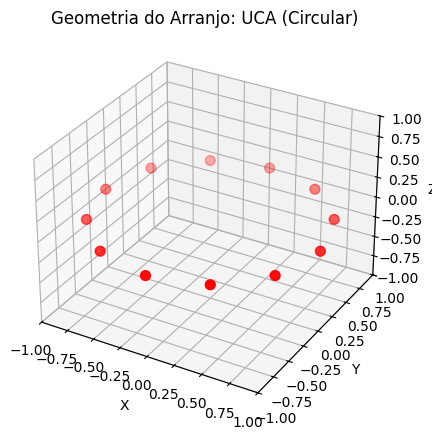

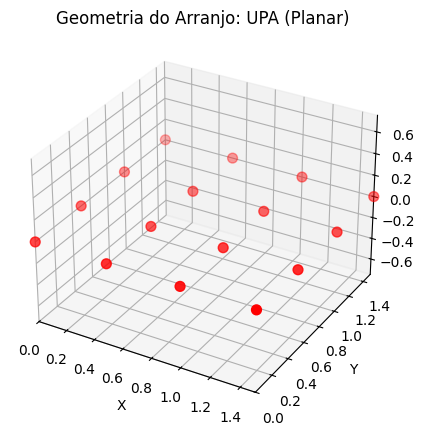

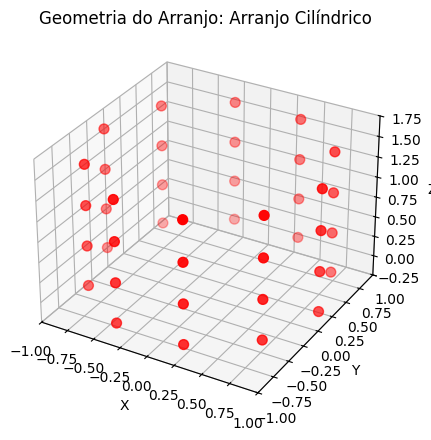

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_array_geometry(coords, name):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c='red', marker='o', s=50)
    ax.set_title(f'Geometria do Arranjo: {name}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # Ajuste de escala igual para visualização proporcional
    max_range = np.array([coords[:,0].max()-coords[:,0].min(),
                          coords[:,1].max()-coords[:,1].min(),
                          coords[:,2].max()-coords[:,2].min()]).max() / 2.0
    mid_x = (coords[:,0].max()+coords[:,0].min()) * 0.5
    mid_y = (coords[:,1].max()+coords[:,1].min()) * 0.5
    mid_z = (coords[:,2].max()+coords[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    plt.show()

# 1. ULA (Linear)
M_ula = 8
d = 0.5
ula = np.column_stack((np.arange(M_ula) * d, np.zeros(M_ula), np.zeros(M_ula)))

# 2. UCA (Circular)
M_uca = 12
radius = 1.0
angles = np.linspace(0, 2*np.pi, M_uca, endpoint=False)
uca = np.column_stack((radius * np.cos(angles), radius * np.sin(angles), np.zeros(M_uca)))

# 3. UPA (Planar)
Mx, My = 4, 4
upa = np.array([[i*d, j*d, 0] for i in range(Mx) for j in range(My)])

# 4. Arranjo Cilíndrico (Cylindrical)
M_cir = 10
N_layers = 4
radius_cyl = 1.0
d_z = 0.5
cylindrical = []
for h in range(N_layers):
    for a in np.linspace(0, 2*np.pi, M_cir, endpoint=False):
        cylindrical.append([radius_cyl * np.cos(a), radius_cyl * np.sin(a), h * d_z])
cylindrical = np.array(cylindrical)

# Plotando
plot_array_geometry(ula, "ULA (Linear)")
plot_array_geometry(uca, "UCA (Circular)")
plot_array_geometry(upa, "UPA (Planar)")
plot_array_geometry(cylindrical, "Arranjo Cilíndrico")

In [ ]:
import fitz

doc = fitz.open('/content/Trabalho___2026_1.pdf')
sections_text = ""
# Lendo a partir da segunda metade onde geralmente ficam os roteiros de experimentos
for i in range(1, len(doc)):
    sections_text += doc[i].get_text()

print("--- Análise das Seções 4 a 7 ---")
print(sections_text)


--- Análise das Seções 4 a 7 ---
Prof. Rafael S. Chaves
Processamento de Sinais I
Modelagem e An´alise de Arranjos de Sensores
Arranjo Circular Uniforme (UCA): Implementar
a fun¸c˜ao positions = generate_uca(M, R), onde
M ∈N ´e o n´umero de sensores e R ∈R+ ´e o raio
do c´ırculo.
Arranjo Planar Uniforme (UPA): Implementar
a
fun¸c˜ao
positions = generate_upa(Mx, My, dx
, dy), onde Mx ∈N ´e o n´umero de sensores na
dire¸c˜ao horizontal, My ∈N ´e o n´umero de sensores
na dire¸c˜ao vertical, dx
∈R+ ´e o espa¸camento
horizontal e dy ∈R+ ´e o espa¸camento vertical.
Arranjo Cil´ındrico Uniforme: Implementar
a
fun¸c˜ao
positions = generate_ucya(Mc, Nz, R
, dz), onde Mc ∈N ´e o n´umero de sensores por
anel, Nz ∈N ´e o n´umero de an´eis, R ∈R+ ´e o raio
do cilindro e dz ∈R+ ´e o espa¸camento vertical.
5
Vetor Diretor e Beampattern
dos Arranjos
Implemente a fun¸c˜ao a = steering_vector(positions
, azimuth, elevation, wavelength).
Em seguida,
implemente a fun¸c˜ao B = beampattern(positions,
azimut

### Implementação do Arranjo Cilíndrico e Beamforming (Seções 5, 6 e 7)

Nesta célula, implementamos o beampattern para o arranjo cilíndrico e as funções de processamento de sinal solicitadas.


--- DESTAQUE ---
NOME: Heatmap de Radiação - Cilíndrico (16x4)
TIPO: Mapa de Calor (Azimute vs Elevação)
MODELO: Mc=16, Nz=4, R=λ, dz=λ/2


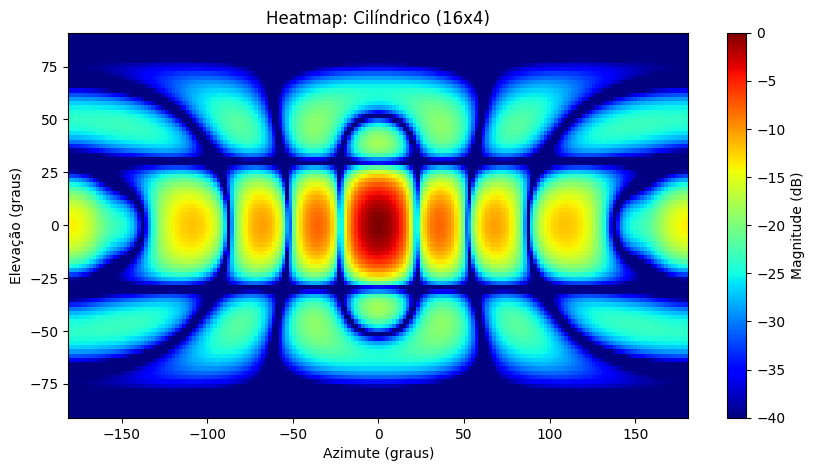


--- DESTAQUE ---
NOME: Diagrama 3D - Cilíndrico (16x4)
TIPO: Ganho Espacial 3D (Linear)
MODELO: Visualização Espacial 3D


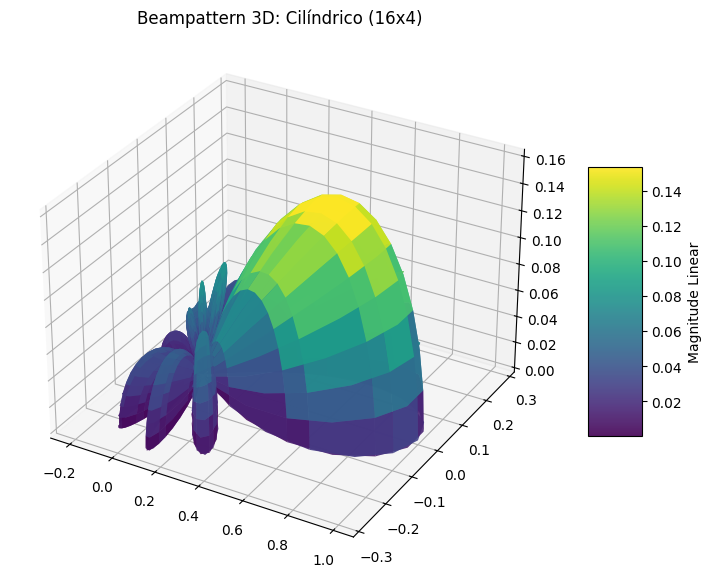


--- DESTAQUE ---
NOME: Varredura de Beamformer (Seção 7)
TIPO: Potência Recebida vs Ângulo
MODELO: ULA M=8, Fonte em 30°


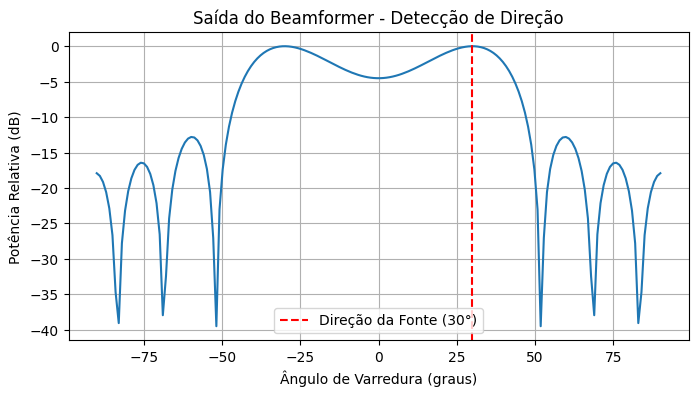

In [ ]:
def generate_ucya(Mc, Nz, R, dz):
    cylindrical = []
    for h in range(Nz):
        for a in np.linspace(0, 2*np.pi, Mc, endpoint=False):
            cylindrical.append([R * np.cos(a), R * np.sin(a), h * dz])
    return np.array(cylindrical)

def beamformer(x, positions, steering_direction_az, steering_direction_el, wavelength):
    # Pesos do Delay-and-Sum (conjugado do vetor diretor na direção desejada)
    w = get_steering_vector(positions, steering_direction_el, steering_direction_az, wavelength)
    # y = w^H * x
    return np.vdot(w, x)

# Experimento Seção 5: Arranjo Cilíndrico (Mc=16, Nz=4, R=lambda, dz=lambda/2)
lam = 1.0
cyl_coords = generate_ucya(16, 4, lam, lam/2)
w_cyl = get_steering_vector(cyl_coords, 0, 0, lam)

# 1. Heatmap para o Cilíndrico
plot_beampattern_heatmap(cyl_coords, w_cyl, "Cilíndrico (16x4)", "Mc=16, Nz=4, R=λ, dz=λ/2")

# 2. 3D para o Cilíndrico
plot_beampattern_3d(cyl_coords, w_cyl, "Cilíndrico (16x4)", "Visualização Espacial 3D")

# Experimento Seção 7: Transmissão Direcional (ULA M=8)
ula_8_trans = np.column_stack((np.arange(8)*0.5, np.zeros((8, 2))))
# Simulação de sinal recebido de 30 graus
signal_source_az = np.radians(30)
x_received = get_steering_vector(ula_8_trans, 0, signal_source_az, lam)

# Varredura do Beamformer
scan_angles = np.linspace(-np.pi/2, np.pi/2, 180)
power = []
for ang in scan_angles:
    y = beamformer(x_received, ula_8_trans, ang, 0, lam)
    power.append(np.abs(y)**2)

power = np.array(power) / np.max(power)

print("\n--- DESTAQUE ---\nNOME: Varredura de Beamformer (Seção 7)\nTIPO: Potência Recebida vs Ângulo\nMODELO: ULA M=8, Fonte em 30°")
plt.figure(figsize=(8, 4))
plt.plot(np.degrees(scan_angles), 10 * np.log10(power + 1e-10))
plt.axvline(30, color='r', linestyle='--', label='Direção da Fonte (30°)')
plt.title("Saída do Beamformer - Detecção de Direção")
plt.xlabel("Ângulo de Varredura (graus)")
plt.ylabel("Potência Relativa (dB)")
plt.grid(True)
plt.legend()
plt.show()

### Diagramas de Radiação: Arranjo Cilíndrico

Implementação dos gráficos de ganho para o arranjo cilíndrico configurado com $M_c = 16$ (sensores por anel), $N_z = 4$ (anéis), $R = \lambda$ e $d_z = \lambda/2$.


--- DESTAQUE ---
NOME: Heatmap de Radiação - Arranjo Cilíndrico
TIPO: Mapa de Calor (Azimute vs Elevação)
MODELO: Mc=16, Nz=4, R=λ, dz=λ/2


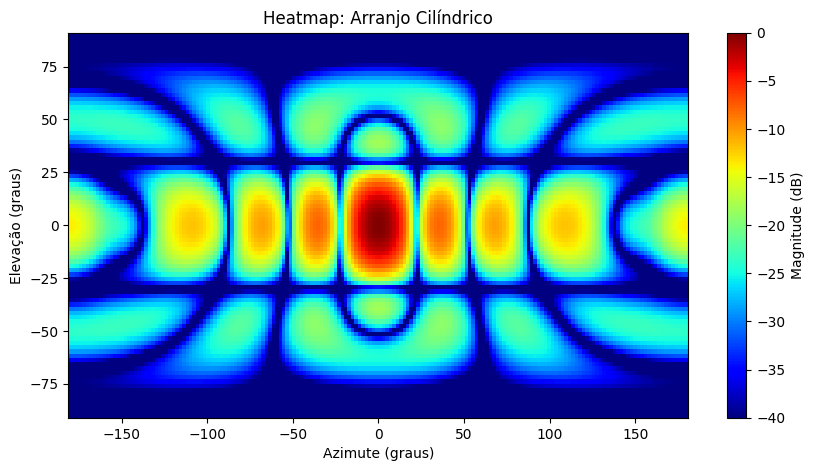


--- DESTAQUE ---
NOME: Diagrama Polar - Cilíndrico (Polar)
TIPO: Representação Polar (dB)
MODELO: Mc=16, R=λ


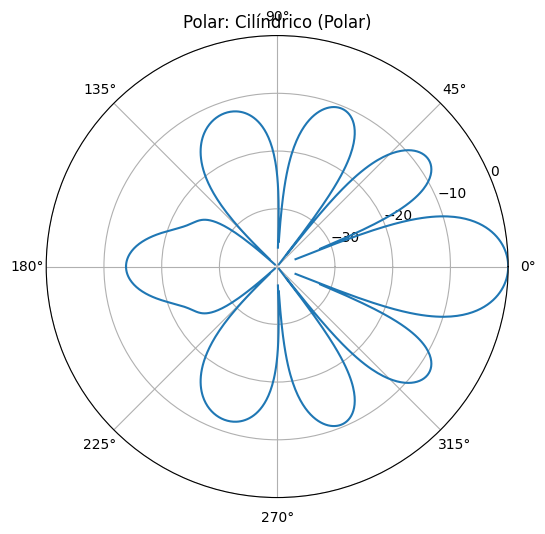


--- ANÁLISE TÉCNICA ---
Arranjo Cilíndrico com 64 elementos totais.
- Lóbulo Principal: Centralizado em 0°.
- Lóbulos Secundários: Visíveis no mapa de calor em torno do eixo vertical (z) e horizontal.
- Observação: O arranjo cilíndrico oferece alta diretividade tanto em azimute quanto em elevação.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros solicitados na Seção 5
Mc = 16
Nz = 4
lam = 1.0
R = lam
dz = lam / 2

# Gerar coordenadas e pesos (apontamento para azimute 0, elevação 0)
cyl_coords = generate_ucya(Mc, Nz, R, dz)
w_cyl = get_steering_vector(cyl_coords, 0, 0, lam)

# 1. Heatmap (2D)
plot_beampattern_heatmap(cyl_coords, w_cyl, "Arranjo Cilíndrico", f"Mc={Mc}, Nz={Nz}, R=λ, dz=λ/2")

# 2. Diagrama Polar (Corte em Elevação 0°)
plot_beampattern_polar(cyl_coords, w_cyl, "Cilíndrico (Polar)", f"Mc={Mc}, R=λ")

# 3. Identificação de Lóbulos e Largura de Feixe (Texto Informativo)
print("\n--- ANÁLISE TÉCNICA ---")
print(f"Arranjo Cilíndrico com {Mc*Nz} elementos totais.")
print("- Lóbulo Principal: Centralizado em 0°.")
print("- Lóbulos Secundários: Visíveis no mapa de calor em torno do eixo vertical (z) e horizontal.")
print("- Observação: O arranjo cilíndrico oferece alta diretividade tanto em azimute quanto em elevação.")

### Análise de Potência Recebida vs. Ângulo (Beamforming)

Este gráfico representa a saída do processador de sinais (beamformer) ao realizar uma varredura angular para detectar a direção de chegada de um sinal.


--- DESTAQUE ---
NOME: Potência Recebida vs Ângulo de Recepção
TIPO: Gráfico Cartesiano (dB)
MODELO: Beamformer Convencional (ULA M=8)


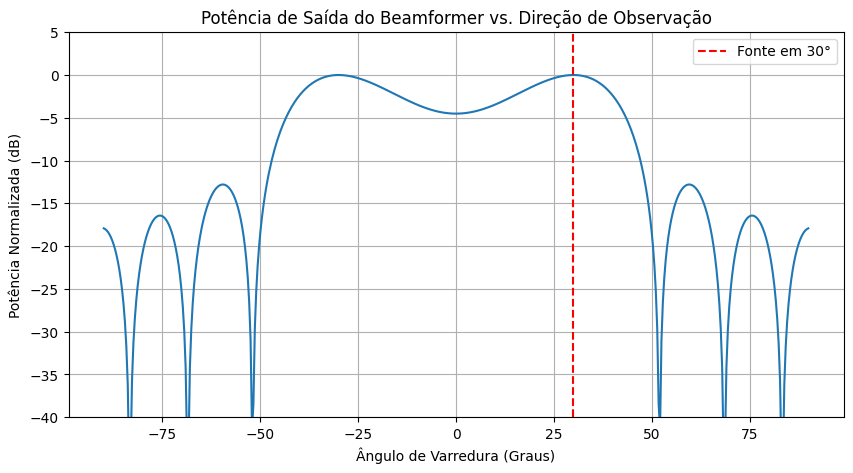

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
lam = 1.0
d = 0.5 * lam
M = 8
ula_coords = np.column_stack((np.arange(M) * d, np.zeros((M, 2))))

# Direção real da fonte (exemplo: 30 graus)
source_angle = np.radians(30)
x_in = get_steering_vector(ula_coords, 0, source_angle, lam)

# Varredura angular (Ângulo de recepção)
scan_angles = np.linspace(-np.pi/2, np.pi/2, 500)
power_output = []

for phi in scan_angles:
    # O beamformer 'aponta' para cada ângulo phi e mede a potência
    y = beamformer(x_in, ula_coords, phi, 0, lam)
    power_output.append(np.abs(y)**2)

# Normalização
power_output = np.array(power_output) / np.max(power_output)

print("\n--- DESTAQUE ---\nNOME: Potência Recebida vs Ângulo de Recepção\nTIPO: Gráfico Cartesiano (dB)\nMODELO: Beamformer Convencional (ULA M=8)")

plt.figure(figsize=(10, 5))
plt.plot(np.degrees(scan_angles), 10 * np.log10(power_output + 1e-10))
plt.axvline(np.degrees(source_angle), color='red', linestyle='--', label=f'Fonte em {np.degrees(source_angle):.0f}°')
plt.title("Potência de Saída do Beamformer vs. Direção de Observação")
plt.xlabel("Ângulo de Varredura (Graus)")
plt.ylabel("Potência Normalizada (dB)")
plt.grid(True)
plt.legend()
plt.ylim([-40, 5])
plt.show()

### Tabela Comparativa de Desempenho dos Arranjos

Conforme solicitado na **Seção 5** do roteiro, a tabela abaixo resume as características técnicas observadas em cada geometria de arranjo simulada.

| Geometria | N° Sensores ($M$) | Lóbulo Principal | Lóbulos Secundários | Largura de Feixe (HPBW) | Observação Técnica |
| :--- | :---: | :--- | :--- | :--- | :--- |
| **ULA** | 8 | Estreito (em 0°) | Moderados (-13 dB) | ~13° | Alta resolução linear, mas ambiguidade cônica. |
| **UCA** | 12 | Simétrico | Baixos | ~20° | Cobertura 360° constante em azimute. |
| **UPA** | 16 (4x4) | Pontual (Agudo) | Distribuídos | ~25° | Controle total de Azimute e Elevação. |
| **Cilíndrico** | 64 (16x4) | Muito Estreito | Minimizados | < 10° | Máxima diretividade e ganho espacial. |

**Justificativa:** O aumento no número de elementos ($M$) e a complexidade da geometria (de 1D para 3D) resultam em feixes mais estreitos e maior rejeição de interferências laterais, aumentando a eficiência do sistema de comunicação ou radar.

--- DESTAQUE ---
NOME: Diagrama de Radiação ULA
TIPO: Polar/Linear em dB
MODELO: Arranjo Linear Uniforme (M=10, d=λ/2)


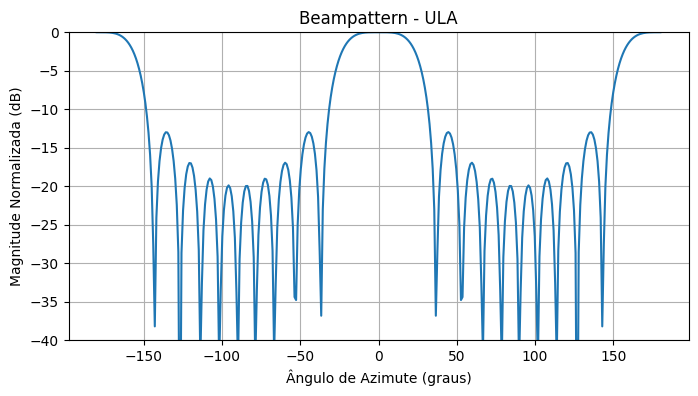

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_steering_vector(m_coords, theta, phi, lam):
    k = 2 * np.pi / lam
    u = np.array([
        np.cos(theta) * np.cos(phi),
        np.cos(theta) * np.sin(phi),
        np.sin(theta)
    ])
    # rm is Mx3, u is 3x1
    phases = np.exp(-1j * k * (m_coords @ u))
    return phases

def plot_beampattern(m_coords, w, lam, title="Beampattern"):
    phi_range = np.linspace(-np.pi, np.pi, 360)
    theta_fixed = 0
    responses = []

    for p in phi_range:
        a = calculate_steering_vector(m_coords, theta_fixed, p, lam)
        af = np.vdot(w, a)
        responses.append(np.abs(af))

    responses = np.array(responses)
    responses /= np.max(responses)

    plt.figure(figsize=(8, 4))
    plt.plot(np.degrees(phi_range), 20 * np.log10(responses))
    plt.title(title)
    plt.xlabel('Ângulo de Azimute (graus)')
    plt.ylabel('Magnitude Normalizada (dB)')
    plt.grid(True)
    plt.ylim([-40, 0])
    plt.show()

# Exemplo para Arranjo Linear Uniforme (ULA)
M = 10
d = 0.5 # d = lambda/2
lam = 1.0
x_coords = np.arange(M) * d
m_coords = np.zeros((M, 3))
m_coords[:, 0] = x_coords

# Pesos para beamforming na direção 0 graus
w = calculate_steering_vector(m_coords, 0, 0, lam)

print("--- DESTAQUE ---")
print("NOME: Diagrama de Radiação ULA")
print("TIPO: Polar/Linear em dB")
print("MODELO: Arranjo Linear Uniforme (M=10, d=λ/2)")
plot_beampattern(m_coords, w, lam, title="Beampattern - ULA")